In [ ]:
#Weather Prediction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,precision_score,recall_score,
                             classification_report, confusion_matrix)
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RNG = 42

In [ ]:
df_model = pd.read_csv("Engineered_Data.csv")

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   temperature_celsius           714 non-null    float64
 1   condition_text                714 non-null    object 
 2   wind_kph                      714 non-null    float64
 3   pressure_mb                   714 non-null    float64
 4   precip_mm                     714 non-null    float64
 5   humidity                      714 non-null    int64  
 6   cloud                         714 non-null    int64  
 7   feels_like_celsius            714 non-null    float64
 8   visibility_km                 714 non-null    float64
 9   uv_index                      714 non-null    float64
 10  gust_kph                      714 non-null    float64
 11  air_quality_Carbon_Monoxide   714 non-null    float64
 12  air_quality_Ozone             714 non-null    float64
 13  air_q

In [ ]:
df_model["date"] = pd.to_datetime(df_model[["year", "month", "day"]])

print(f"Rows: {len(df_model)}   |   Date range: {df_model['date'].min().date()} -> {df_model['date'].max().date()}")
df_model[["date", "temperature_celsius", "humidity", "wind_kph", "precip_mm", "condition_text"]].tail()

Rows: 714   |   Date range: 2024-05-16 -> 2026-05-03


,date,temperature_celsius,humidity,wind_kph,precip_mm,condition_text
709,2026-04-29,38.4,33,16.2,0.00,Clear
710,2026-04-30,31.3,66,17.6,0.06,Rain
711,2026-05-01,24.2,94,20.5,0.00,Thunder
712,2026-05-02,36.3,45,20.5,0.00,Cloudy
713,2026-05-03,35.1,50,18.4,0.00,Thunder


In [ ]:
df_model['Delta_celsius'] = abs(df_model['temperature_celsius'] - df_model['feels_like_celsius'])

df_model = df_model.drop(columns=['feels_like_celsius', 'air_quality_Carbon_Monoxide' ,'air_quality_Ozone' , 'air_quality_Nitrogen_dioxide' , 'air_quality_Sulphur_dioxide' , 'air_quality_PM2.5' , 'air_quality_PM10' , 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_phase' , 'moon_illumination' , 'pm_lag' ])

df_model['condition_text'] = df_model['condition_text'].replace('Drizzle', 'Cloudy')
df_model['condition_text'] = df_model['condition_text'].replace('Thunder', 'Rain')

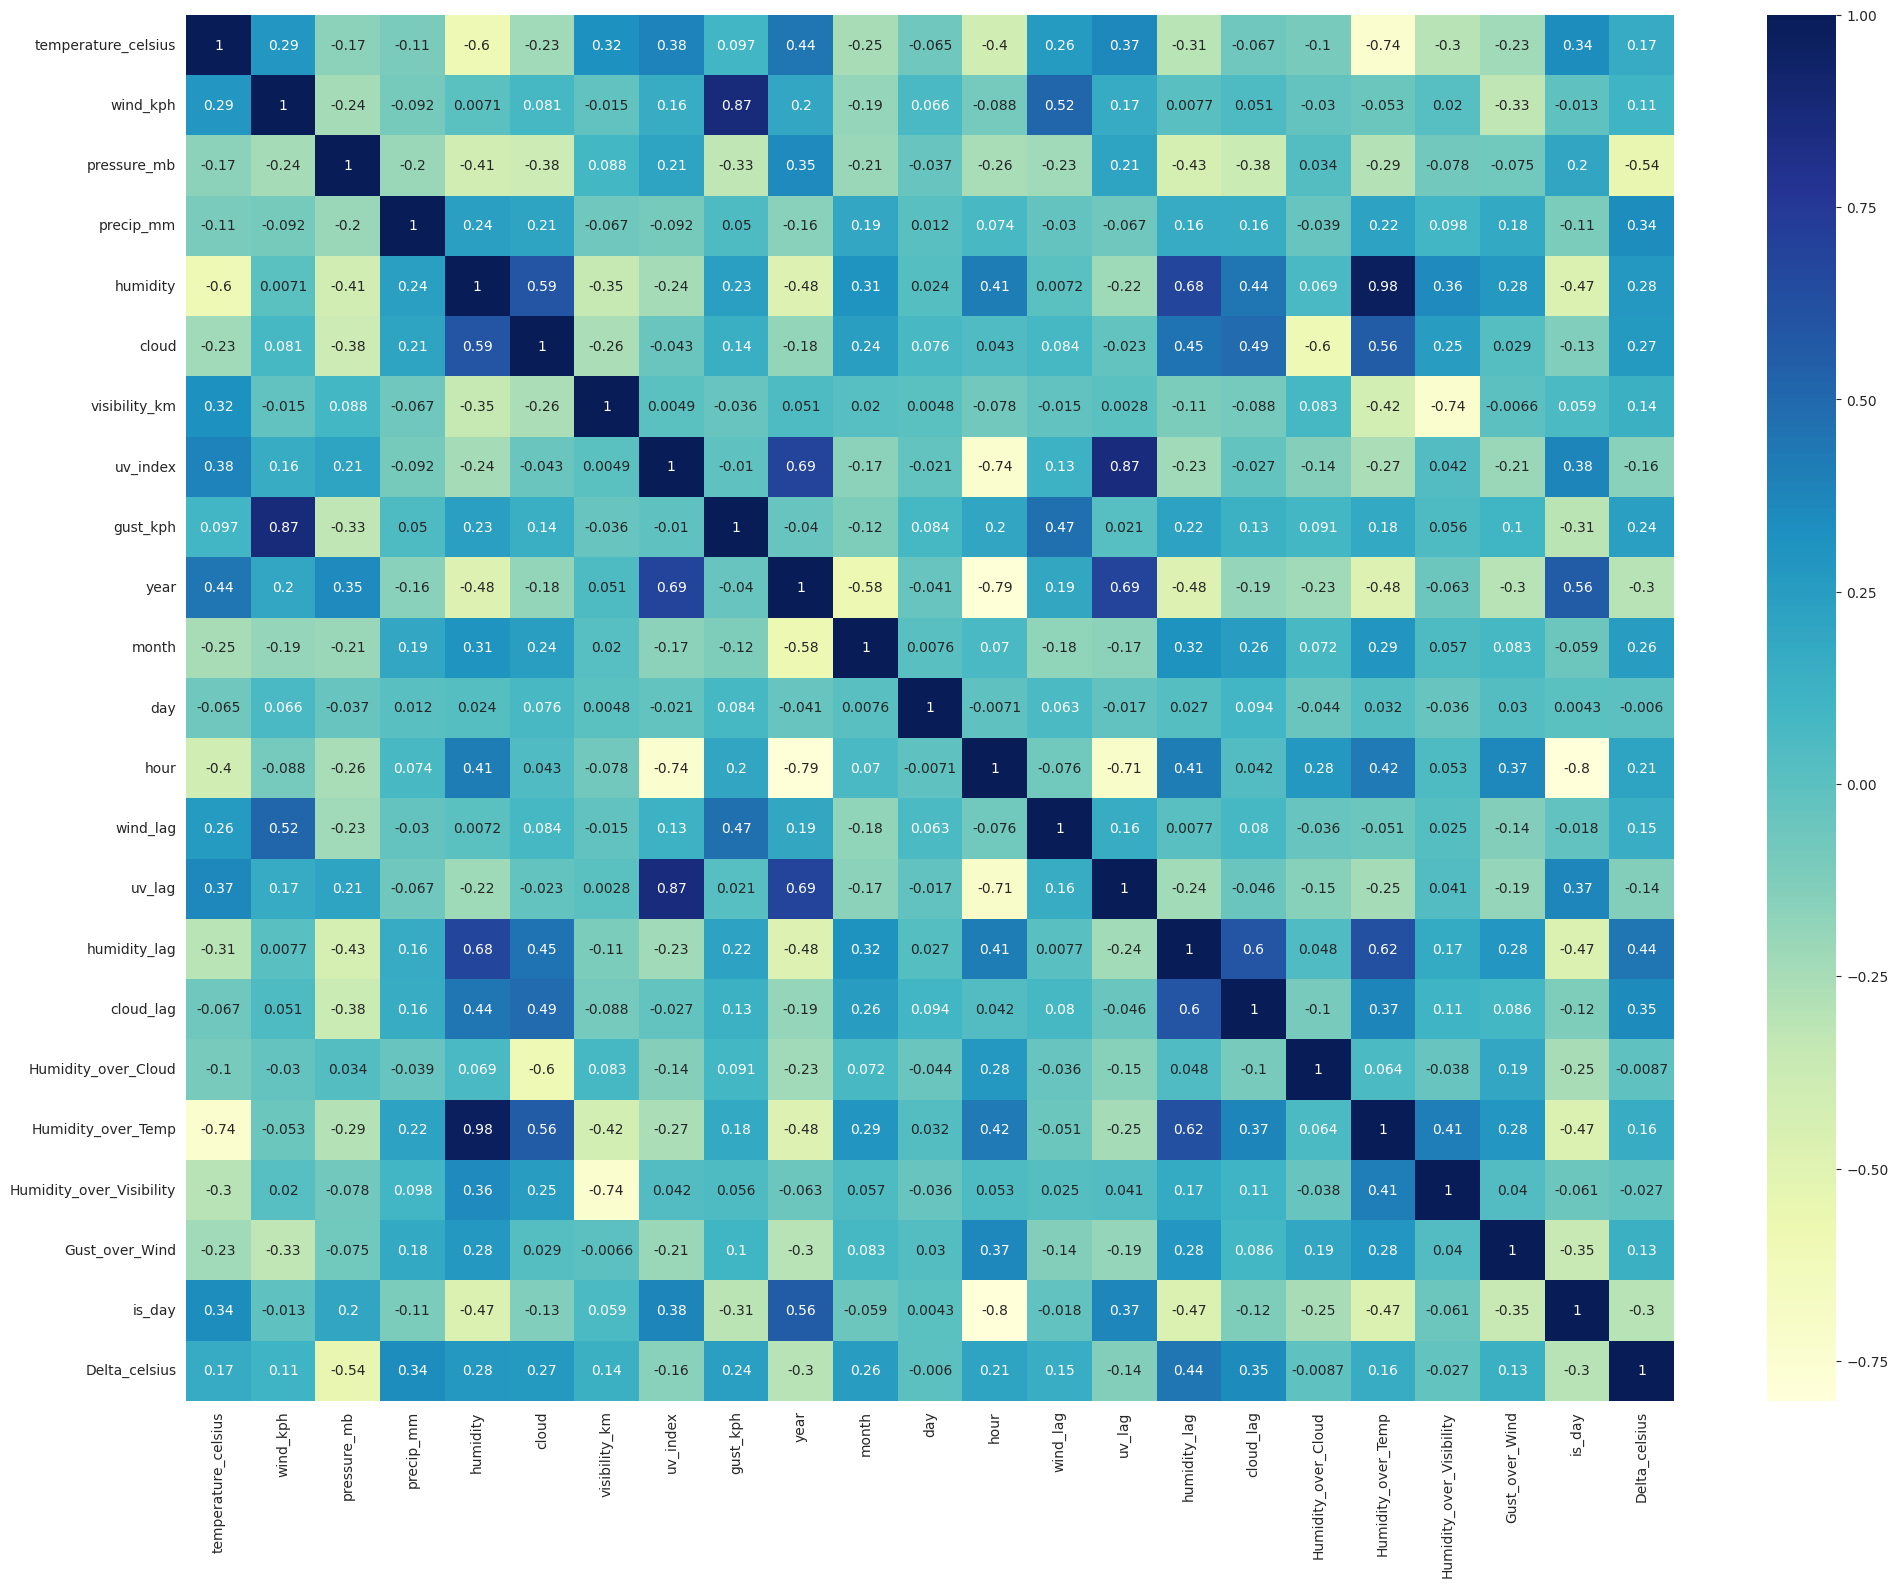

In [ ]:
plt.figure(figsize=(24, 18))
co_mtx = df_model.corr(numeric_only=True)
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.show()

In [ ]:
LAG_COLS = ["temperature_celsius", "humidity", "wind_kph", "precip_mm",
            "pressure_mb", "cloud", "uv_index"]


def add_model_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["dayofyear"] = d["date"].dt.dayofyear
    d["doy_sin"]   = np.sin(2 * np.pi * d["dayofyear"] / 365.25)
    d["doy_cos"]   = np.cos(2 * np.pi * d["dayofyear"] / 365.25)
    for c in LAG_COLS:
        for lag in [1, 2, 3, 7]:
            d[f"{c}_lag{lag}"] = d[c].shift(lag)
        d[f"{c}_roll3"] = d[c].shift(1).rolling(3).mean()
        d[f"{c}_roll7"] = d[c].shift(1).rolling(7).mean()
    return d.dropna(subset=LAG_COLS).reset_index(drop=True)

data = add_model_features(df_model)
print("After feature engineering:", data.shape)
data.info()

After feature engineering: (714, 72)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 72 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   temperature_celsius        714 non-null    float64       
 1   condition_text             714 non-null    object        
 2   wind_kph                   714 non-null    float64       
 3   pressure_mb                714 non-null    float64       
 4   precip_mm                  714 non-null    float64       
 5   humidity                   714 non-null    int64         
 6   cloud                      714 non-null    int64         
 7   visibility_km              714 non-null    float64       
 8   uv_index                   714 non-null    float64       
 9   gust_kph                   714 non-null    float64       
 10  year                       714 non-null    int64         
 11  month                      714 non

In [ ]:
TEST_START = pd.Timestamp("2026-03-02")
TEST_END   = pd.Timestamp("2026-05-02")


train = data[data["date"] < TEST_START].copy()
test  = data[(data["date"] >= TEST_START) & (data["date"] <= TEST_END)].copy()


X_train = train.drop('condition_text', axis=1)


y_train = train['condition_text']

X_test = test.drop('condition_text', axis=1)
y_test = test['condition_text']

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
print(train["date"].max(), test["date"].min())

(651, 71) (62, 71)
(651,) (62,)
2026-03-01 00:00:00 2026-03-02 00:00:00


In [ ]:
cols_to_drop = ['date', 'year_month']
X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

X_train = pd.get_dummies(X_train, columns=['season'])
X_test  = pd.get_dummies(X_test,  columns=['season'])

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)


In [ ]:
num_classes = len(le.classes_)

weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_encoded
)

model = XGBClassifier(
    objective='multi:softmax',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    num_class=num_classes
)

model.fit(X_train, y_train_encoded, sample_weight=weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=3, ...)

<Figure size 1200x3200 with 0 Axes>

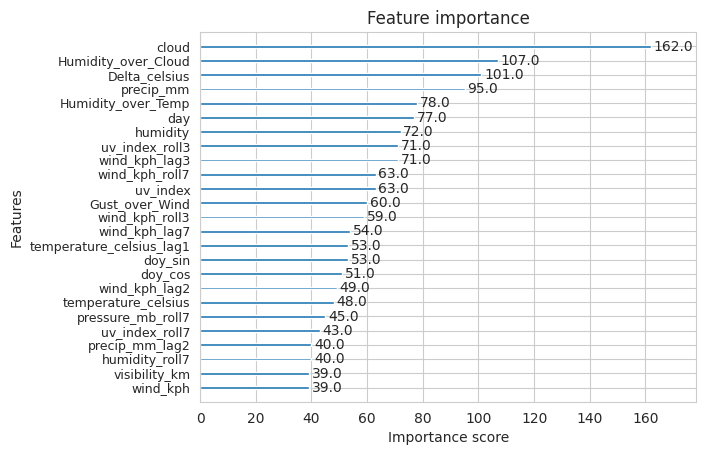

Accuracy: 0.8387


In [ ]:
plt.figure(figsize=(12, 32))
ax = xgb.plot_importance(model, max_num_features=25)
ax.tick_params(axis='y', labelsize=9)
plt.show()


y_pred = model.predict(X_test)
acc = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {acc:.4f}")

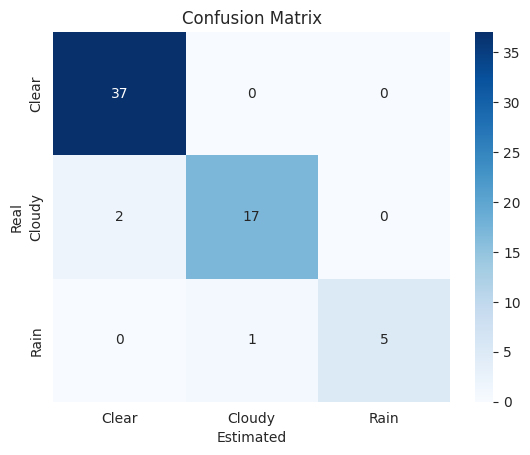

[0 1 2]
[0 1 2]


In [ ]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Estimated")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()


print(np.unique(y_test_encoded))
print(np.unique(y_pred))

In [ ]:
np.unique(y_train_encoded, return_counts=True)

(array([0, 1, 2]), array([124, 431,  96]))

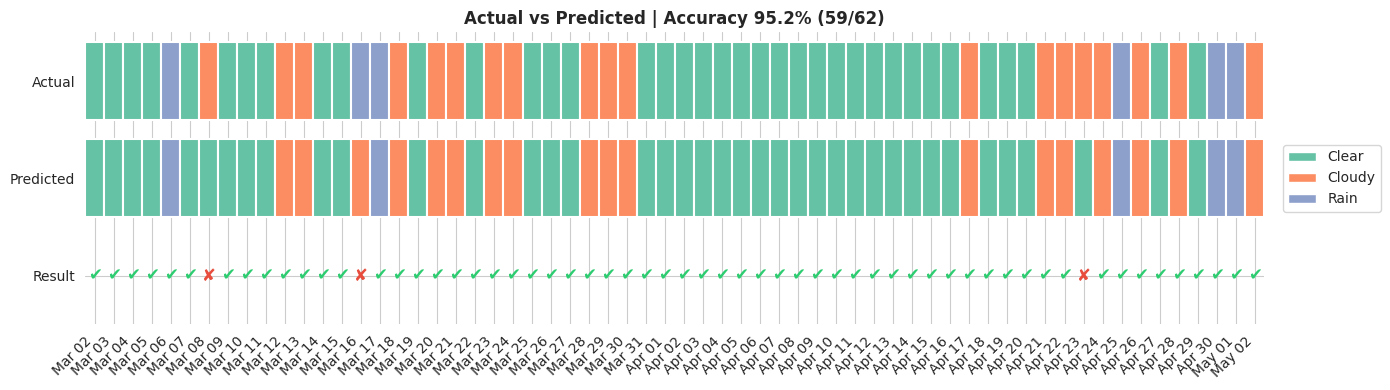

F1 Score: 0.9507
Accuracy: 0.9516
Precision: 0.9524
Recall: 0.9516


In [ ]:
y_pred_labels = le.inverse_transform(y_pred)

cmp = pd.DataFrame({
    "date": test["date"].values,
    "condition_actual": y_test.values,
    "condition_pred": y_pred_labels
})

cmp["correct"] = cmp["condition_actual"] == cmp["condition_pred"]

all_classes = sorted(set(cmp['condition_actual']) | set(cmp['condition_pred']))
palette = dict(zip(all_classes, sns.color_palette('Set2', len(all_classes))))

fig, ax = plt.subplots(figsize=(14, 4))
n = len(cmp)

for i, row in cmp.reset_index(drop=True).iterrows():
    # Actual
    ax.barh(y=2, width=1, left=i,
            color=palette[row['condition_actual']],
            edgecolor='white', linewidth=1.5)

    # Predicted
    ax.barh(y=1, width=1, left=i,
            color=palette[row['condition_pred']],
            edgecolor='white', linewidth=1.5)

    # Result
    correct = row['correct']
    ax.text(i + 0.5, 0,
            '✔' if correct else '✘',
            ha='center', va='center', fontsize=12,
            color='#2ecc71' if correct else '#e74c3c',
            fontweight='bold')

# Axis formatting
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Result', 'Predicted', 'Actual'])
ax.set_ylim(-0.5, 2.5)

ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(
    [d.strftime('%b %d') for d in cmp['date']],
    rotation=45, ha='right'
)

ax.set_xlim(0, n)

# Legend
legend_elems = [Patch(facecolor=palette[c], label=c) for c in all_classes]
ax.legend(handles=legend_elems, bbox_to_anchor=(1.01, 0.5), loc='center left')

# Title
acc = cmp['correct'].mean()
ax.set_title(
    f"Actual vs Predicted | Accuracy {acc:.1%} ({cmp['correct'].sum()}/{n})",
    fontweight='bold'
)

ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.show()

f1 = f1_score(y_test_encoded, y_pred, average='weighted')
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall = recall_score(y_test_encoded, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

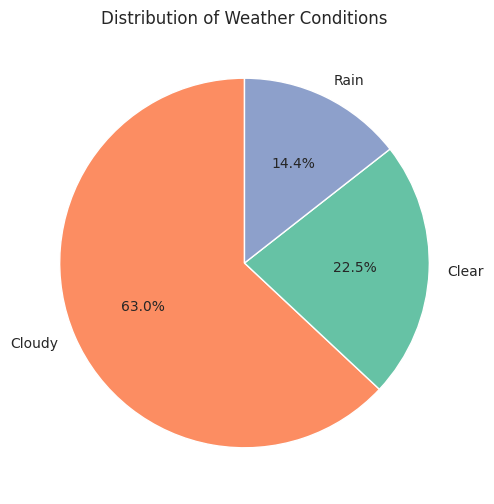

In [ ]:


counts = df_model['condition_text'].value_counts()

colors = ['#FC8D62','#66C2A5','#8DA0CB']
plt.figure(figsize=(6,6))
counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=colors  )

plt.title('Distribution of Weather Conditions')
plt.ylabel('')
plt.show()